=== Category Mapping ===
  ID 0 → with_mask
  ID 1 → without_mask
  ID 2 → mask_weared_incorrect

=== Class Distribution Summary ===
Class                          ID    Count      Percentage   Imbalance Ratio
----------------------------------------------------------------------
with_mask                      0     159        35.18       % 1.00x
without_mask                   1     154        34.07       % 1.03x
mask_weared_incorrect          2     139        30.75       % 1.14x

Total Annotations: 452


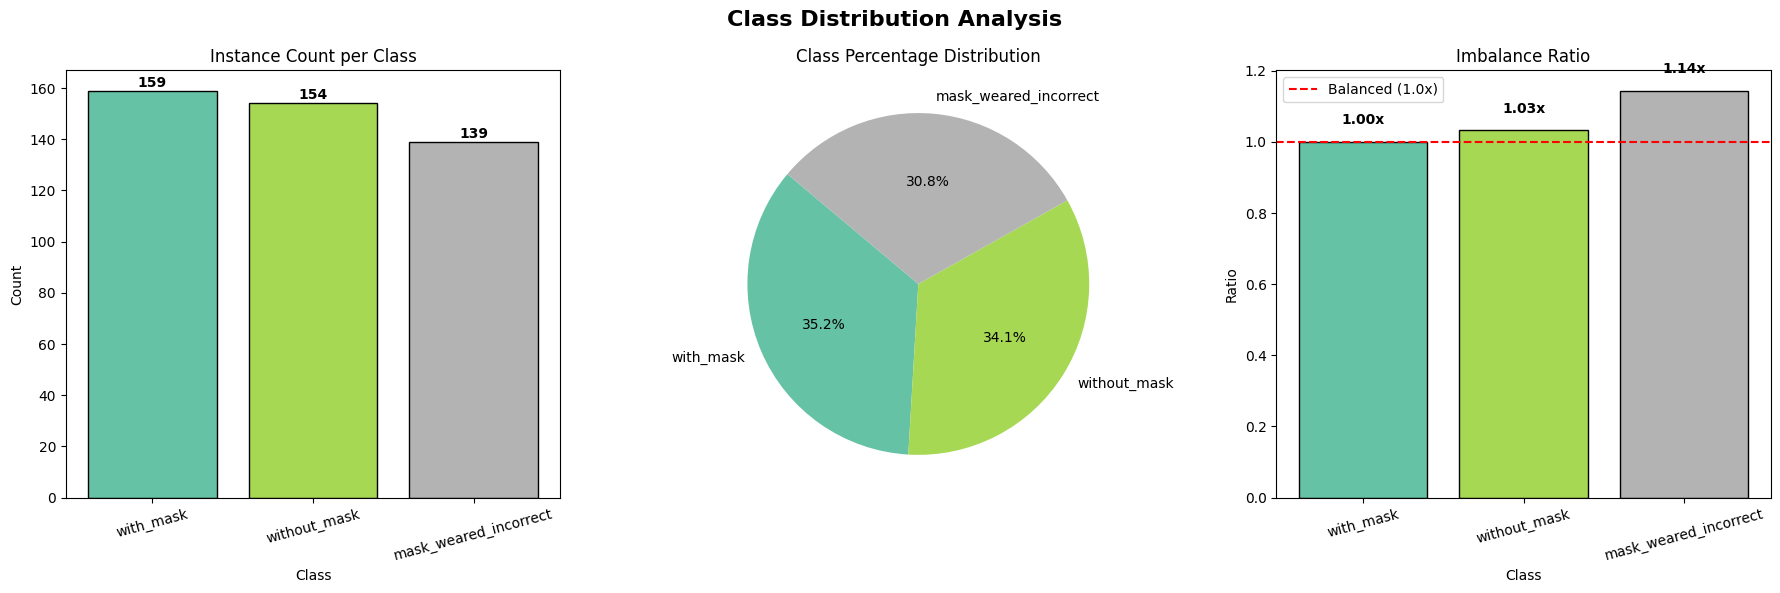

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load annotations.json
with open("/kaggle/input/datasets/arbmonty/face-mask-wearing-condition-detection/annotations.json") as f:
    data = json.load(f)

# Category Mapping
cat_map = {cat["id"]: cat["name"] for cat in data["categories"]}
print("=== Category Mapping ===")
for cid, cname in cat_map.items():
    print(f"  ID {cid} → {cname}")

# Instance Count
counts = Counter()
for ann in data["annotations"]:
    counts[ann["category_id"]] += 1

total = sum(counts.values())

# Summary Table
print("\n=== Class Distribution Summary ===")
print(f"{'Class':<30} {'ID':<5} {'Count':<10} {'Percentage':<12} {'Imbalance Ratio'}")
print("-" * 70)

max_count = max(counts.values())
names, instance_counts, percentages, ratios = [], [], [], []

for cid, cname in cat_map.items():
    count   = counts.get(cid, 0)
    percent = (count / total) * 100
    ratio   = max_count / count if count > 0 else float("inf")
    names.append(cname)
    instance_counts.append(count)
    percentages.append(percent)
    ratios.append(ratio)
    print(f"{cname:<30} {cid:<5} {count:<10} {percent:<12.2f}% {ratio:.2f}x")

print(f"\nTotal Annotations: {total}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Class Distribution Analysis", fontsize=16, fontweight="bold")
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

# Bar chart
bars = axes[0].bar(names, instance_counts, color=colors, edgecolor="black")
axes[0].set_title("Instance Count per Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, instance_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(instance_counts)*0.01,
                 str(val), ha="center", fontsize=10, fontweight="bold")

# Pie chart
axes[1].pie(percentages, labels=names, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class Percentage Distribution")

# Imbalance ratio
bars2 = axes[2].bar(names, ratios, color=colors, edgecolor="black")
axes[2].set_title("Imbalance Ratio")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Ratio")
axes[2].tick_params(axis="x", rotation=15) 
axes[2].axhline(y=1, color="red", linestyle="--", label="Balanced (1.0x)")
axes[2].legend()
for bar, val in zip(bars2, ratios):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{val:.2f}x", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Using device: cuda
Loading dataset...
Total: 452 | Train: 362 | Val: 90
Building Faster R-CNN + ResNet50 FPN...
Model ready — 4 classes (0=bg, 1=with_mask, 2=without_mask, 3=mask_weared_incorrect)

Starting Training


Epoch 01/30 [Val]  : 100%|██████████| 23/23 [00:12<00:00,  1.79it/s, val_loss=0.221]



Epoch 01 | Train: 0.2531 | Val: 0.1777 | LR: 0.005000
  ✅ best_train_loss.pth saved  (train=0.2531)
  ✅ best_val_loss.pth saved    (val=0.1777)
------------------------------------------------------------


Epoch 02/30 [Val]  : 100%|██████████| 23/23 [00:12<00:00,  1.79it/s, val_loss=0.128]



Epoch 02 | Train: 0.1555 | Val: 0.1275 | LR: 0.005000
  ✅ best_train_loss.pth saved  (train=0.1555)
  ✅ best_val_loss.pth saved    (val=0.1275)
------------------------------------------------------------


...


Epoch 28 | Train: 0.0728 | Val: 0.0749 | LR: 0.000050
  ✅ best_train_loss.pth saved  (train=0.0728)
------------------------------------------------------------


Epoch 29/30 [Val]  : 100%|██████████| 23/23 [00:12<00:00,  1.79it/s, val_loss=0.085]



Epoch 29 | Train: 0.0725 | Val: 0.0738 | LR: 0.000050
  ✅ best_train_loss.pth saved  (train=0.0725)
------------------------------------------------------------


Epoch 30/30 [Val]  : 100%|██████████| 23/23 [00:12<00:00,  1.81it/s, val_loss=0.085]



Epoch 30 | Train: 0.0727 | Val: 0.0739 | LR: 0.000005
------------------------------------------------------------
✅ final_epoch.pth saved


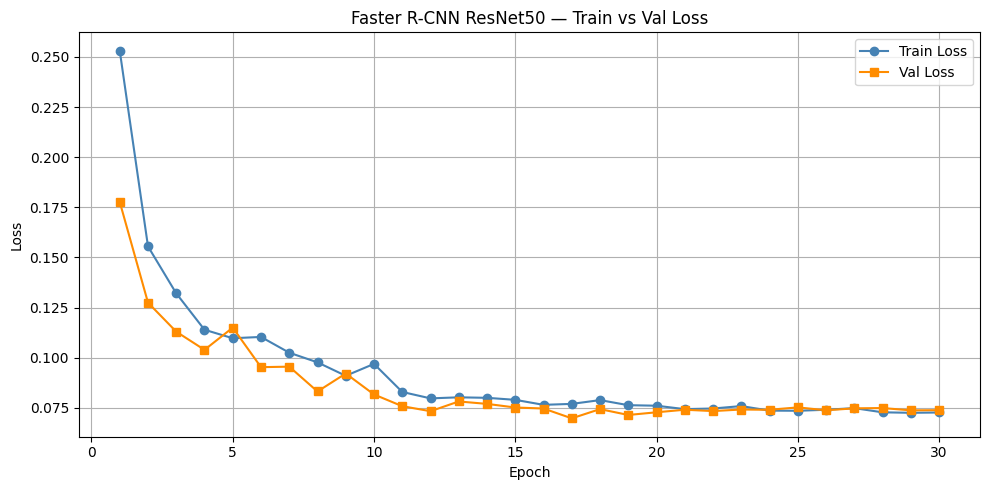


Training Complete!
  Best Train Loss : 0.0725
  Best Val Loss   : 0.0698
  Saved → best_train_loss.pth | best_val_loss.pth | final_epoch.pth


In [3]:
"""
Faster R-CNN + ResNet50 FPN — Face Mask Detection
Dataset  : COCO-format annotations.json
GPU      : Kaggle T4
Split    : 80% train / 20% val
Saves    : best_train_loss.pth | best_val_loss.pth | final_epoch.pth
Augment  : Heavy (flip, color jitter, blur, grayscale, perspective, cutout)
"""

import os, json, random
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── 1. CONFIG ─────────────────────────────────────────────────────────
ANNOTATIONS = "/kaggle/input/datasets/arbmonty/face-mask-wearing-condition-detection/annotations.json"
IMAGES_DIR  = "/kaggle/input/datasets/arbmonty/face-mask-wearing-condition-detection/Images/Images"
OUTPUT_DIR  = "/kaggle/working"

NUM_CLASSES  = 4
NUM_EPOCHS   = 30
BATCH_SIZE   = 4
LR           = 0.005
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
VAL_SPLIT    = 0.2
SEED         = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ── 2. AUGMENTATIONS (fixed for albumentations 2.x) ───────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomRotate90(p=0.2),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2, p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(p=0.3),
    A.ToGray(p=0.1),                          # fixed: was RandomGrayscale
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    min_holes=1, fill_value=0, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format="coco", label_fields=["class_labels"], min_visibility=0.3))

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format="coco", label_fields=["class_labels"], min_visibility=0.3))


# ── 3. DATASET ────────────────────────────────────────────────────────
class MaskDataset(Dataset):
    def __init__(self, annotations_file, images_dir, transform=None):
        with open(annotations_file) as f:
            self.coco = json.load(f)
        self.images_dir = images_dir
        self.transform  = transform
        self.img_map    = {img["id"]: img for img in self.coco["images"]}
        self.ann_map    = defaultdict(list)
        for ann in self.coco["annotations"]:
            self.ann_map[ann["image_id"]].append(ann)
        self.img_ids = list(self.img_map.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.img_map[img_id]
        anns     = self.ann_map[img_id]

        img_path = os.path.join(self.images_dir, img_info["file_name"])
        image    = np.array(Image.open(img_path).convert("RGB"))

        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w > 1 and h > 1:
                boxes.append([x, y, w, h])
                labels.append(ann["category_id"] + 1)

        if self.transform and len(boxes) > 0:
            out    = self.transform(image=image, bboxes=boxes, class_labels=labels)
            image  = out["image"]
            boxes  = list(out["bboxes"])
            labels = list(out["class_labels"])
        else:
            plain = A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
            image = plain(image=image)["image"]

        converted = [[x, y, x+w, y+h] for x, y, w, h in boxes]

        if len(converted) == 0:
            target = {"boxes":  torch.zeros((0,4), dtype=torch.float32),
                      "labels": torch.zeros((0,),  dtype=torch.int64),
                      "image_id": torch.tensor([img_id])}
        else:
            target = {"boxes":  torch.tensor(converted, dtype=torch.float32),
                      "labels": torch.tensor(labels,    dtype=torch.int64),
                      "image_id": torch.tensor([img_id])}
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


# ── 4. LOAD & SPLIT ───────────────────────────────────────────────────
print("Loading dataset...")
total      = len(MaskDataset(ANNOTATIONS, IMAGES_DIR))
val_size   = int(total * VAL_SPLIT)
train_size = total - val_size
indices    = list(range(total))
random.shuffle(indices)
train_idx, val_idx = indices[:train_size], indices[train_size:]
print(f"Total: {total} | Train: {train_size} | Val: {val_size}")

train_dataset = Subset(MaskDataset(ANNOTATIONS, IMAGES_DIR, transform=train_transform), train_idx)
val_dataset   = Subset(MaskDataset(ANNOTATIONS, IMAGES_DIR, transform=val_transform),   val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)


# ── 5. MODEL ──────────────────────────────────────────────────────────
print("Building Faster R-CNN + ResNet50 FPN...")
model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)
print(f"Model ready — {NUM_CLASSES} classes (0=bg, 1=with_mask, 2=without_mask, 3=mask_weared_incorrect)")


# ── 6. OPTIMIZER & SCHEDULER ──────────────────────────────────────────
params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


# ── 7. TRAINING LOOP ──────────────────────────────────────────────────
train_losses, val_losses = [], []
best_train_loss = float("inf")
best_val_loss   = float("inf")

print("\n" + "="*60)
print("Starting Training")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):

    # TRAIN
    model.train()
    epoch_train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]", leave=True)

    for images, targets in pbar:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        epoch_train_loss += losses.item()
        pbar.set_postfix({
            "total": f"{losses.item():.3f}",
            "cls"  : f"{loss_dict.get('loss_classifier',  torch.tensor(0)).item():.3f}",
            "box"  : f"{loss_dict.get('loss_box_reg',     torch.tensor(0)).item():.3f}",
            "rpn"  : f"{loss_dict.get('loss_rpn_box_reg', torch.tensor(0)).item():.3f}",
            "obj"  : f"{loss_dict.get('loss_objectness',  torch.tensor(0)).item():.3f}",
        })

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # VALIDATION
    model.train()
    epoch_val_loss = 0.0
    pbar_v = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Val]  ", leave=True)

    with torch.no_grad():
        for images, targets in pbar_v:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict      = model(images, targets)
            losses         = sum(loss for loss in loss_dict.values())
            epoch_val_loss += losses.item()
            pbar_v.set_postfix({"val_loss": f"{losses.item():.3f}"})

    avg_val = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step()

    print(f"\nEpoch {epoch:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    if avg_train < best_train_loss:
        best_train_loss = avg_train
        torch.save({"epoch": epoch, "train_loss": avg_train, "val_loss": avg_val,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict()},
                   f"{OUTPUT_DIR}/best_train_loss.pth")
        print(f"  ✅ best_train_loss.pth saved  (train={best_train_loss:.4f})")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({"epoch": epoch, "train_loss": avg_train, "val_loss": avg_val,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict()},
                   f"{OUTPUT_DIR}/best_val_loss.pth")
        print(f"  ✅ best_val_loss.pth saved    (val={best_val_loss:.4f})")

    print("-" * 60)

# SAVE FINAL
torch.save({"epoch": NUM_EPOCHS, "train_loss": train_losses[-1], "val_loss": val_losses[-1],
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()},
           f"{OUTPUT_DIR}/final_epoch.pth")
print("✅ final_epoch.pth saved")


# ── 8. LOSS CURVE ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker="o", color="steelblue")
plt.plot(range(1, NUM_EPOCHS+1), val_losses,   label="Val Loss",   marker="s", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN ResNet50 — Train vs Val Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("Training Complete!")
print(f"  Best Train Loss : {best_train_loss:.4f}")
print(f"  Best Val Loss   : {best_val_loss:.4f}")
print("  Saved → best_train_loss.pth | best_val_loss.pth | final_epoch.pth")
print("="*60)


In [26]:

# ============================================
# FACE MASK DETECTION MODEL EVALUATION
# FINAL REVISED VERSION
# ============================================

# Install required libraries
!pip install torchmetrics pycocotools -q

# ============================================
# IMPORTS
# ============================================

import torch
import torchvision
import numpy as np

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

# ============================================
# DEVICE
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ============================================
# MODEL CONFIGURATION
# ============================================

# IMPORTANT:
# Your trained model uses 4 classes
# (including background)

num_classes = 4

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# ============================================
# LOAD CHECKPOINT
# ============================================

checkpoint = torch.load(
    "/kaggle/input/models/arbmonty/v-1/pytorch/default/1/best_val_loss.pth",
    map_location=device
)

# Load ONLY model weights
model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)
model.eval()

print("\nModel loaded successfully!")

print("\nCheckpoint Details:")
print("Epoch      :", checkpoint["epoch"])
print("Train Loss :", checkpoint["train_loss"])
print("Val Loss   :", checkpoint["val_loss"])

# ============================================
# IMPORTANT
# ============================================

# val_loader MUST already exist
# from your training notebook

# Example:
#
# val_loader = DataLoader(
#     val_dataset,
#     batch_size=4,
#     shuffle=False,
#     collate_fn=collate_fn
# )

# ============================================
# METRIC INITIALIZATION
# ============================================

metric = MeanAveragePrecision()

all_ious = []

TP = 0
FP = 0
FN = 0

# ============================================
# EVALUATION LOOP
# ============================================

with torch.no_grad():

    for images, targets in tqdm(val_loader):

        images = [img.to(device) for img in images]

        outputs = model(images)

        preds = []
        gts = []

        for output, target in zip(outputs, targets):

            # ----------------------------
            # Predictions
            # ----------------------------

            pred_boxes = output["boxes"].cpu()
            pred_scores = output["scores"].cpu()
            pred_labels = output["labels"].cpu()

            # ----------------------------
            # Ground Truth
            # ----------------------------

            true_boxes = target["boxes"].cpu()
            true_labels = target["labels"].cpu()

            preds.append({
                "boxes": pred_boxes,
                "scores": pred_scores,
                "labels": pred_labels
            })

            gts.append({
                "boxes": true_boxes,
                "labels": true_labels
            })

            # ----------------------------
            # IoU Calculation
            # ----------------------------

            if len(pred_boxes) > 0 and len(true_boxes) > 0:

                iou_matrix = box_iou(
                    pred_boxes,
                    true_boxes
                )

                max_iou = iou_matrix.max(dim=1).values

                all_ious.extend(max_iou.tolist())

                TP += (max_iou > 0.5).sum().item()

                FP += (max_iou <= 0.5).sum().item()

                FN += max(
                    0,
                    len(true_boxes) - (max_iou > 0.5).sum().item()
                )

            else:

                FP += len(pred_boxes)

                FN += len(true_boxes)

        metric.update(preds, gts)

# ============================================
# COMPUTE mAP
# ============================================

results = metric.compute()

map50 = results["map_50"].item()

map5095 = results["map"].item()

# ============================================
# PRECISION / RECALL / F1
# ============================================

precision = TP / (TP + FP + 1e-6)

recall = TP / (TP + FN + 1e-6)

f1_score = (
    2 * precision * recall
) / (
    precision + recall + 1e-6
)

# ============================================
# ACCURACY
# ============================================

accuracy = TP / (
    TP + FP + FN + 1e-6
)

# ============================================
# MEAN IoU
# ============================================

mean_iou = np.mean(all_ious)

# ============================================
# FINAL RESULTS
# ============================================

print("\n====================================")
print("        FINAL EVALUATION")
print("====================================\n")

print(f"Accuracy         : {accuracy:.4f}")

print(f"Precision        : {precision:.4f}")

print(f"Recall           : {recall:.4f}")

print(f"F1 Score         : {f1_score:.4f}")

print(f"\nmAP@0.5          : {map50:.4f}")

print(f"mAP@0.5:0.95     : {map5095:.4f}")

print(f"\nMean IoU         : {mean_iou:.4f}")

print("\n====================================")



Using device: cuda

Model loaded successfully!

Checkpoint Details:
Epoch      : 17
Train Loss : 0.07698253100062465
Val Loss   : 0.06977616137136584


100%|██████████| 23/23 [00:13<00:00,  1.71it/s]



        FINAL EVALUATION

Accuracy         : 0.7200
Precision        : 0.7200
Recall           : 1.0000
F1 Score         : 0.8372

mAP@0.5          : 0.9051
mAP@0.5:0.95     : 0.6599

Mean IoU         : 0.6464



Using Device: cuda
Model Loaded Successfully!


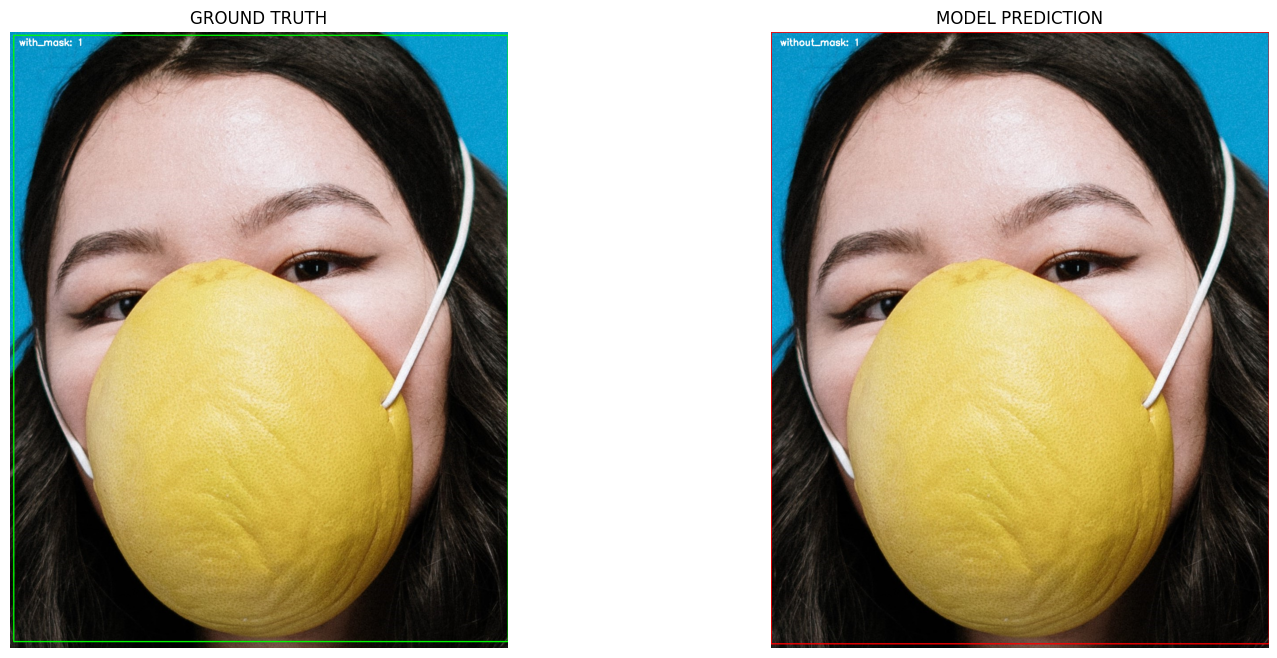

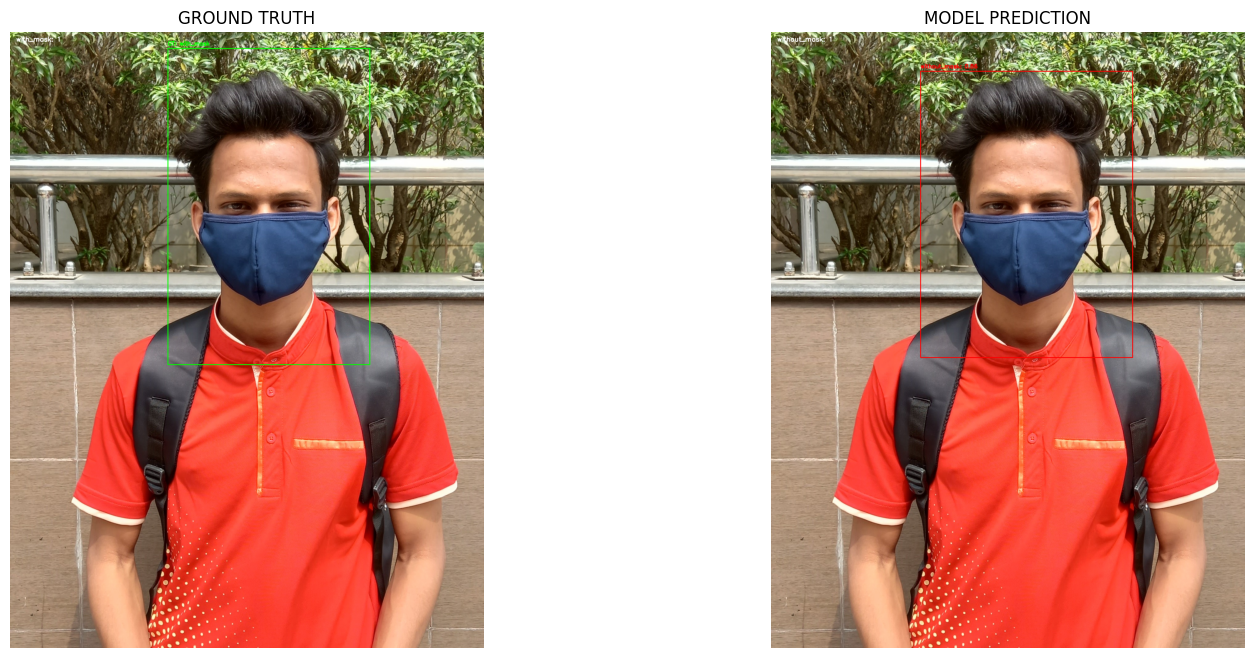

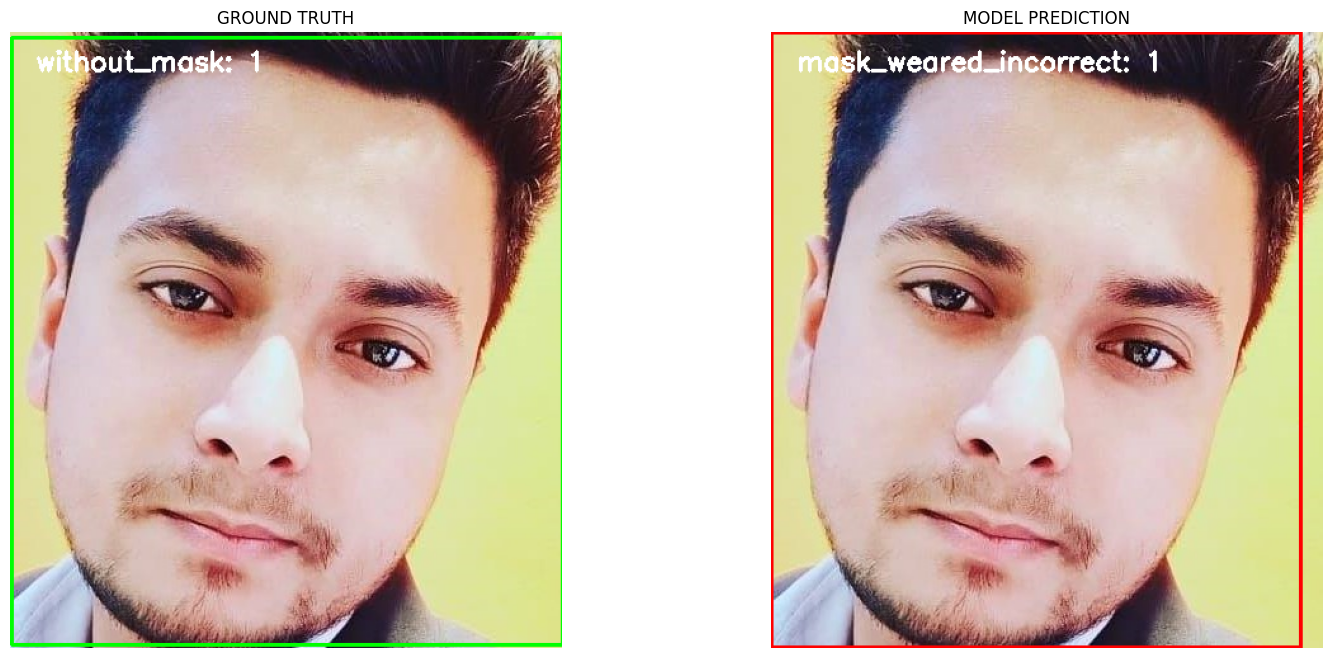

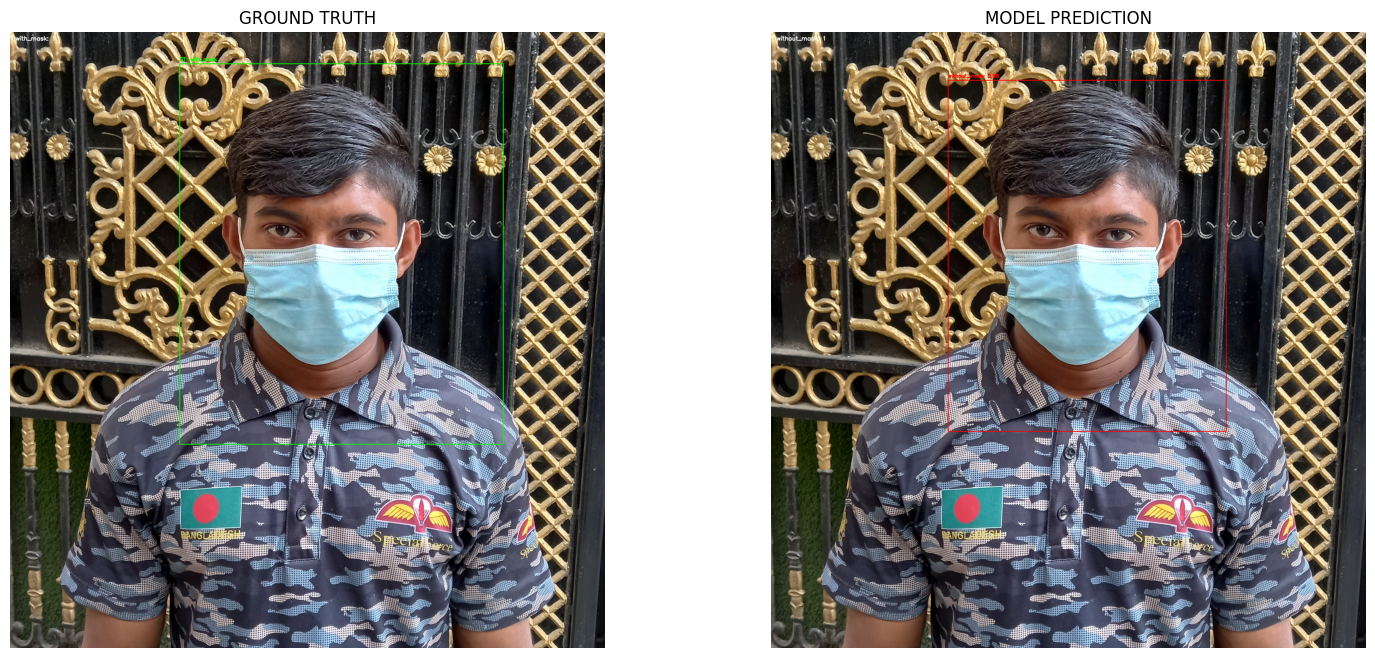

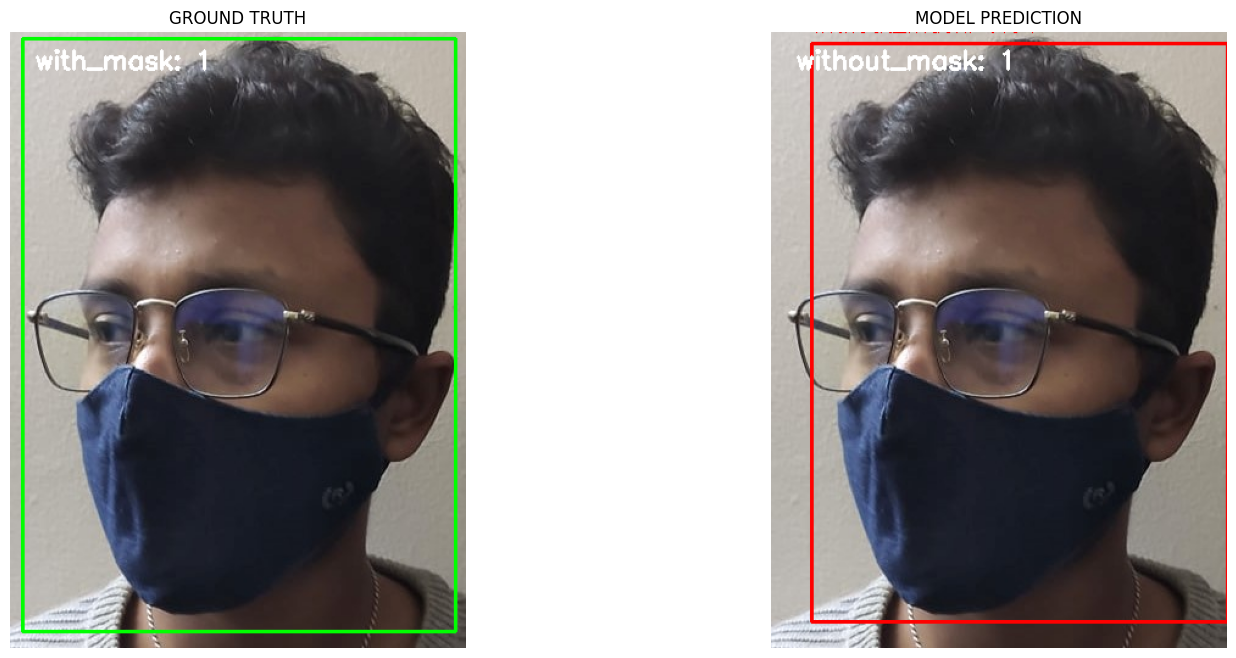

In [27]:
# =========================================================
# GROUND TRUTH vs MODEL PREDICTION
# USING annotations.json
# =========================================================

import os
import cv2
import json
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from PIL import Image
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# =========================================================
# PATHS
# =========================================================

IMAGES_FOLDER = "/kaggle/input/datasets/arbmonty/face-mask-wearing-condition-detection/Images/Images"

ANNOTATION_FILE = "/kaggle/input/datasets/arbmonty/face-mask-wearing-condition-detection/annotations.json"

MODEL_PATH = "/kaggle/input/models/arbmonty/v-1/pytorch/default/1/best_val_loss.pth"

# =========================================================
# SETTINGS
# =========================================================

NUM_IMAGES_TO_SHOW = 5

CONFIDENCE_THRESHOLD = 0.5

CLASS_NAMES = {
    1: "with_mask",
    2: "without_mask",
    3: "mask_weared_incorrect"
}

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

# =========================================================
# LOAD ANNOTATIONS
# =========================================================

with open(ANNOTATION_FILE, "r") as f:
    coco_data = json.load(f)

# Create image dictionary
image_info = {}

for img in coco_data["images"]:

    image_info[img["id"]] = {
        "file_name": img["file_name"],
        "annotations": []
    }

# Add annotations
for ann in coco_data["annotations"]:

    image_id = ann["image_id"]

    image_info[image_id]["annotations"].append(ann)

# =========================================================
# LOAD MODEL
# =========================================================

num_classes = 4

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None
)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)

model.eval()

print("Model Loaded Successfully!")

# =========================================================
# SELECT RANDOM IMAGES
# =========================================================

all_image_ids = list(image_info.keys())

random.shuffle(all_image_ids)

selected_ids = all_image_ids[:NUM_IMAGES_TO_SHOW]

# =========================================================
# VISUALIZATION LOOP
# =========================================================

for image_id in selected_ids:

    file_name = image_info[image_id]["file_name"]

    image_path = os.path.join(
        IMAGES_FOLDER,
        file_name
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    gt_image = image.copy()

    pred_image = image.copy()

    # =====================================================
    # DRAW GROUND TRUTH
    # =====================================================

    gt_counts = {}

    for ann in image_info[image_id]["annotations"]:

        x, y, w, h = ann["bbox"]

        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)

        class_id = ann["category_id"]

        class_name = CLASS_NAMES[class_id]

        gt_counts[class_name] = gt_counts.get(
            class_name,
            0
        ) + 1

        # GREEN BOX
        cv2.rectangle(
            gt_image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            gt_image,
            f"GT: {class_name}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # =====================================================
    # DRAW GROUND TRUTH COUNTS
    # =====================================================

    y_pos = 30

    for cls, count in gt_counts.items():

        cv2.putText(
            gt_image,
            f"{cls}: {count}",
            (20, y_pos),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        y_pos += 30

    # =====================================================
    # MODEL PREDICTION
    # =====================================================

    image_pil = Image.fromarray(image)

    image_tensor = F.to_tensor(
        image_pil
    ).to(device)

    with torch.no_grad():

        output = model([image_tensor])[0]

    boxes = output["boxes"].cpu().numpy()

    scores = output["scores"].cpu().numpy()

    labels = output["labels"].cpu().numpy()

    pred_counts = {}

    # =====================================================
    # DRAW PREDICTIONS
    # =====================================================

    for box, score, label in zip(
        boxes,
        scores,
        labels
    ):

        if score < CONFIDENCE_THRESHOLD:
            continue

        x1, y1, x2, y2 = map(int, box)

        class_name = CLASS_NAMES[label]

        pred_counts[class_name] = pred_counts.get(
            class_name,
            0
        ) + 1

        # RED BOX
        cv2.rectangle(
            pred_image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        cv2.putText(
            pred_image,
            f"{class_name}: {score:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    # =====================================================
    # DRAW PREDICTION COUNTS
    # =====================================================

    y_pos = 30

    for cls, count in pred_counts.items():

        cv2.putText(
            pred_image,
            f"{cls}: {count}",
            (20, y_pos),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        y_pos += 30

    # =====================================================
    # DISPLAY
    # =====================================================

    plt.figure(figsize=(18, 8))

    plt.subplot(1, 2, 1)

    plt.imshow(gt_image)

    plt.title("GROUND TRUTH")

    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(pred_image)

    plt.title("MODEL PREDICTION")

    plt.axis("off")

    plt.show()